# Data Science Workshop — Data Analysis & Visualization Projects
### 2 Mini Projects: Exploratory Data Analysis in Practice

| # | Project | Domain | Focus |
|---|---------|--------|-------|
| 1 | E-commerce Sales & Customer Analysis | Retail / E-commerce | Trends, seasonality, category & customer behaviour |
| 2 | HR Employee Attrition Analysis | Human Resources | Attrition drivers, department/tenure patterns |

Each project follows: **Generate Data → Clean/Prepare → Explore → Visualize → Insights**


## 0. Setup — Common Imports
Run this cell first. It is used by both projects below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.


---
## Project 1 — E-commerce Sales & Customer Analysis

**Goal:** analyze a year of e-commerce transactions to answer common
business questions:
- How do sales trend over the year? Is there seasonality?
- Which product categories and regions perform best?
- How do discounts affect order value?
- Who are the top customers?

No modeling here — just careful, honest exploratory data analysis (EDA).


### 1.1 Generate Synthetic Data

In [2]:
n_orders = 5000

dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
order_dates = np.random.choice(dates, size=n_orders)

categories = ["Electronics", "Clothing", "Home & Kitchen", "Beauty", "Sports", "Books"]
category_base_price = {"Electronics": 250, "Clothing": 45, "Home & Kitchen": 70,
                        "Beauty": 30, "Sports": 60, "Books": 20}
category_weights = [0.22, 0.25, 0.18, 0.15, 0.12, 0.08]

regions = ["North", "South", "East", "West"]

order_category = np.random.choice(categories, size=n_orders, p=category_weights)
order_region = np.random.choice(regions, size=n_orders, p=[0.3, 0.25, 0.25, 0.2])
customer_id = np.random.randint(1, 1200, size=n_orders)  # some customers order repeatedly

# Seasonality: boost sales around Nov (festive/Black Friday) and Dec (holidays)
month = pd.Series(order_dates).dt.month
seasonal_multiplier = month.map({
    1: 0.9, 2: 0.85, 3: 0.9, 4: 0.95, 5: 1.0, 6: 1.0,
    7: 0.95, 8: 0.95, 9: 1.0, 10: 1.1, 11: 1.5, 12: 1.4
}).values

base_price = pd.Series(order_category).map(category_base_price).values
quantity = np.random.randint(1, 5, size=n_orders)
discount_pct = np.random.choice([0, 5, 10, 15, 20, 30], size=n_orders, p=[0.35, 0.2, 0.2, 0.12, 0.08, 0.05])

unit_price = base_price * np.random.normal(1, 0.15, n_orders).clip(0.6, 1.6)
gross_amount = unit_price * quantity * seasonal_multiplier
order_amount = (gross_amount * (1 - discount_pct / 100)).round(2)

df_orders = pd.DataFrame({
    "order_date": order_dates,
    "customer_id": customer_id,
    "region": order_region,
    "category": order_category,
    "quantity": quantity,
    "discount_pct": discount_pct,
    "order_amount": order_amount
}).sort_values("order_date").reset_index(drop=True)

df_orders.head()


,order_date,customer_id,region,category,quantity,discount_pct,order_amount
0,2024-01-01,791,East,Electronics,2,5,466.91
1,2024-01-01,108,North,Home & Kitchen,4,0,285.97
2,2024-01-01,991,East,Home & Kitchen,3,0,192.12
3,2024-01-01,28,West,Home & Kitchen,1,5,60.80
4,2024-01-01,1146,South,Books,1,5,15.75


### 1.2 Data Preparation

In [3]:
# Basic checks
print(df_orders.shape)
print(df_orders.isna().sum())

# Add helper columns for grouping
df_orders["month"] = df_orders["order_date"].dt.to_period("M").astype(str)
df_orders["day_of_week"] = df_orders["order_date"].dt.day_name()

df_orders.describe()


(5000, 7)
order_date      0
customer_id     0
region          0
category        0
quantity        0
discount_pct    0
order_amount    0
dtype: int64


,order_date,customer_id,quantity,discount_pct,order_amount
count,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-06-30 22:57:12.960000,603.384600,2.519800,7.956000,223.152346
min,2024-01-01 00:00:00,1.000000,1.000000,0.000000,11.280000
25%,2024-04-02 00:00:00,306.000000,2.000000,0.000000,66.847500
50%,2024-06-27 00:00:00,608.000000,3.000000,5.000000,128.170000
75%,2024-10-01 00:00:00,899.000000,4.000000,15.000000,235.997500
max,2024-12-31 00:00:00,1199.000000,4.000000,30.000000,1665.590000
std,NaN,344.436046,1.117792,8.267148,259.252713


### 1.3 Sales Trend Over Time

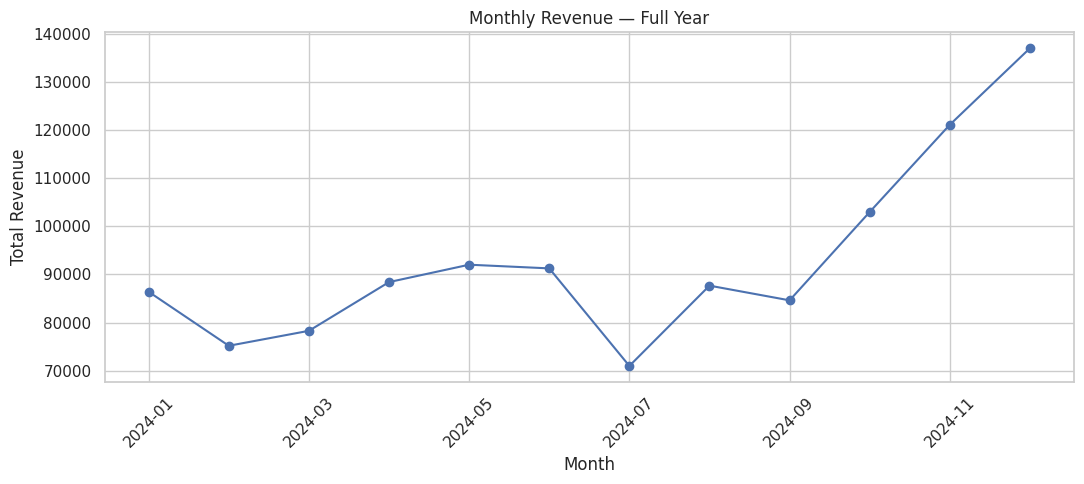

In [4]:
monthly_sales = df_orders.groupby("month")["order_amount"].sum()

plt.figure(figsize=(11, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue — Full Year")
plt.ylabel("Total Revenue")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** revenue rises sharply in November and December — a
seasonality pattern we deliberately built into the simulation, mirroring
real festive/holiday shopping spikes.


### 1.4 Category & Region Performance

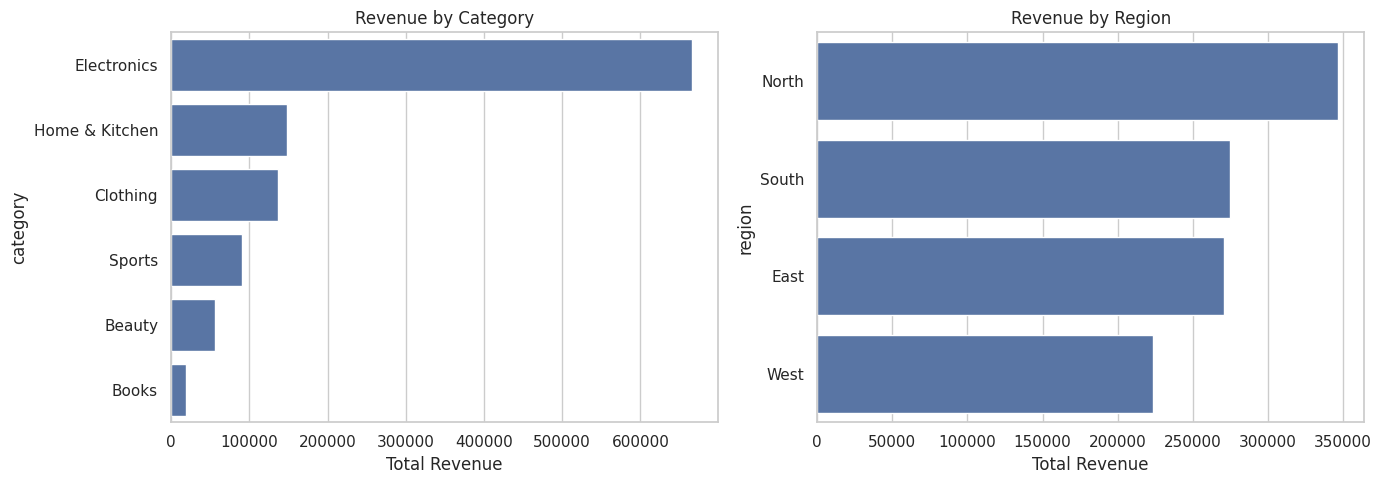

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales = df_orders.groupby("category")["order_amount"].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0])
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Total Revenue")

region_sales = df_orders.groupby("region")["order_amount"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.values, y=region_sales.index, ax=axes[1])
axes[1].set_title("Revenue by Region")
axes[1].set_xlabel("Total Revenue")

plt.tight_layout()
plt.show()


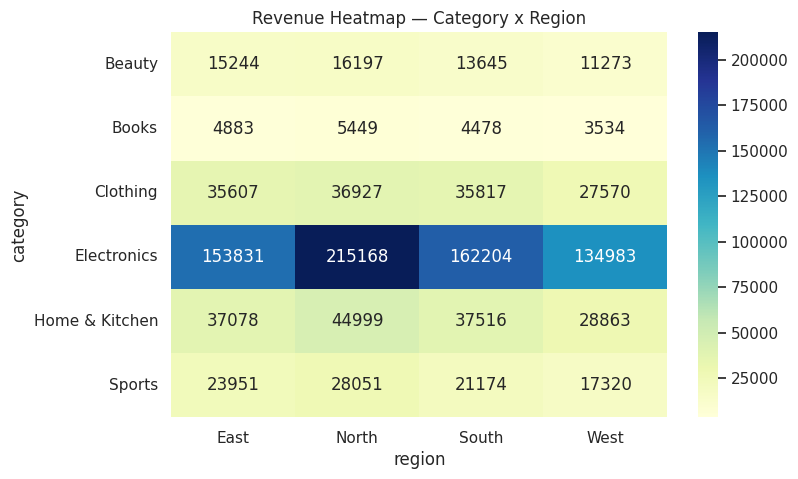

In [6]:
pivot = df_orders.pivot_table(index="category", columns="region", values="order_amount", aggfunc="sum")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenue Heatmap — Category x Region")
plt.show()


### 1.5 Discount Impact on Order Value

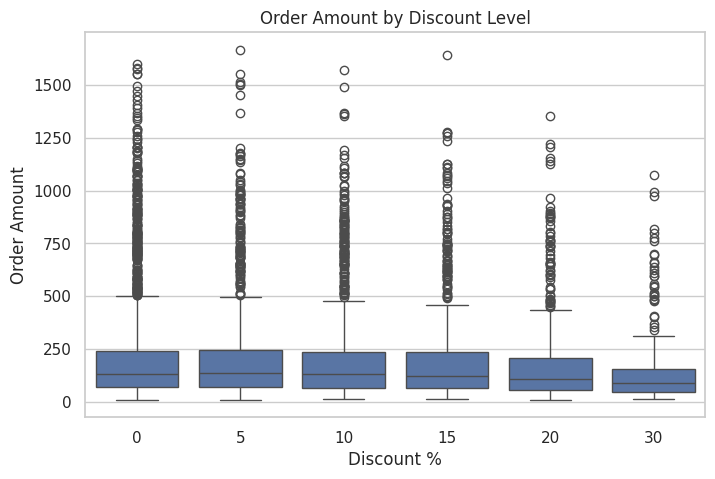

discount_pct
0     232.17
5     232.58
10    223.41
15    223.69
20    203.24
30    155.97
Name: order_amount, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_orders, x="discount_pct", y="order_amount")
plt.title("Order Amount by Discount Level")
plt.xlabel("Discount %")
plt.ylabel("Order Amount")
plt.show()

print(df_orders.groupby("discount_pct")["order_amount"].mean().round(2))


### 1.6 Day-of-Week Ordering Pattern

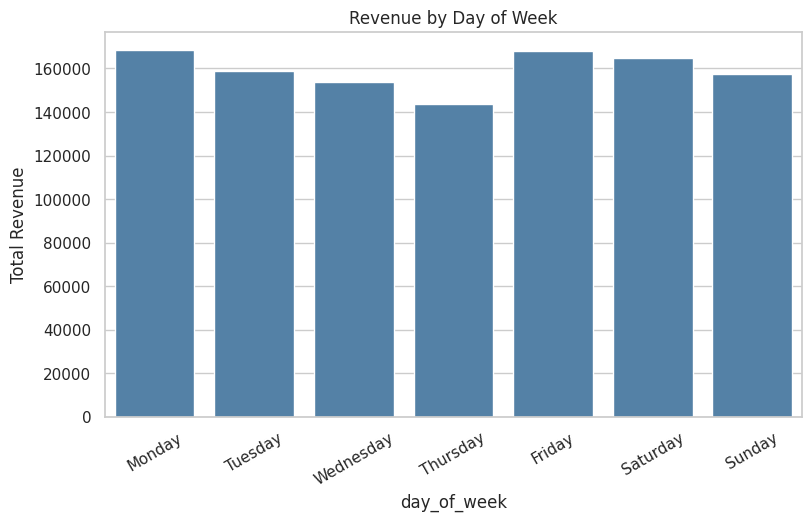

In [8]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = df_orders.groupby("day_of_week")["order_amount"].sum().reindex(dow_order)

plt.figure(figsize=(9, 5))
sns.barplot(x=dow_sales.index, y=dow_sales.values, color="steelblue")
plt.title("Revenue by Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()


### 1.7 Top Customers

In [9]:
top_customers = (
    df_orders.groupby("customer_id")["order_amount"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "total_spent", "count": "num_orders"})
    .sort_values("total_spent", ascending=False)
    .head(10)
)

top_customers


,total_spent,num_orders
customer_id,,
1145,4527.48,12
481,3665.50,7
992,3652.98,8
239,3397.48,8
259,3354.32,7
689,3340.46,8
85,3338.07,4
1093,3336.43,7
576,3141.82,10


**Takeaways for the workshop:** this project shows the analyst's core loop —
group, aggregate, visualize, interpret — without ever training a model.
Discuss with participants: which chart type best answers each business
question, and why (line for trend, bar for comparison, heatmap for two
categorical dimensions, box plot for distribution comparison)?


---
## Project 2 — HR Employee Attrition Analysis

**Goal:** explore a simulated company workforce dataset to understand
patterns behind employee attrition (who leaves, and why) — a very common
real-world "Data Analysis & Visualization" project (inspired by the classic
IBM HR Analytics dataset).


### 2.1 Generate Synthetic Data

In [10]:
n_employees = 1400

departments = ["Sales", "R&D", "HR", "Engineering", "Marketing"]
dept_weights = [0.25, 0.2, 0.1, 0.3, 0.15]

department = np.random.choice(departments, size=n_employees, p=dept_weights)
age = np.random.randint(21, 60, n_employees)
years_at_company = np.random.randint(0, 25, n_employees)
monthly_income = np.round(np.random.normal(6000, 2500, n_employees).clip(2000, 20000), 0)
job_satisfaction = np.random.randint(1, 5, n_employees)  # 1=Low ... 4=Very High
work_life_balance = np.random.randint(1, 5, n_employees)
overtime = np.random.choice(["Yes", "No"], size=n_employees, p=[0.3, 0.7])
distance_from_home = np.random.randint(1, 30, n_employees)

# Build attrition probability: higher risk with low satisfaction, overtime,
# low tenure, long commute, low income relative to age/tenure
z = (
    -1.5
    - 0.35 * (job_satisfaction - 2.5)
    - 0.25 * (work_life_balance - 2.5)
    + 0.55 * (overtime == "Yes").astype(int)
    - 0.05 * years_at_company
    + 0.03 * distance_from_home
    - 0.0002 * (monthly_income - 6000)
    + np.random.normal(0, 0.7, n_employees)
)
attrition_prob = 1 / (1 + np.exp(-z))
attrition = np.where(attrition_prob > np.random.uniform(0.4, 0.6, n_employees), "Yes", "No")

df_hr = pd.DataFrame({
    "department": department,
    "age": age,
    "years_at_company": years_at_company,
    "monthly_income": monthly_income,
    "job_satisfaction": job_satisfaction,
    "work_life_balance": work_life_balance,
    "overtime": overtime,
    "distance_from_home": distance_from_home,
    "attrition": attrition
})

df_hr.head()


,department,age,years_at_company,monthly_income,job_satisfaction,work_life_balance,overtime,distance_from_home,attrition
0,Engineering,22,11,6786.0,4,2,No,23,No
1,R&D,25,0,3747.0,1,2,Yes,27,Yes
2,HR,38,21,4283.0,2,1,No,29,No
3,Engineering,49,20,7806.0,3,1,No,14,No
4,R&D,30,8,5030.0,1,2,No,7,Yes


### 2.2 Data Preparation & Overview

In [11]:
print(df_hr.shape)
print(df_hr.isna().sum())
print("\nOverall attrition rate:", (df_hr["attrition"] == "Yes").mean().round(3))

df_hr.describe()


(1400, 9)
department            0
age                   0
years_at_company      0
monthly_income        0
job_satisfaction      0
work_life_balance     0
overtime              0
distance_from_home    0
attrition             0
dtype: int64

Overall attrition rate: 0.1


,age,years_at_company,monthly_income,job_satisfaction,work_life_balance,distance_from_home
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,39.459286,12.175714,6045.977857,2.514286,2.508571,15.226429
std,11.369223,7.157314,2430.118576,1.124716,1.119678,8.274906
min,21.000000,0.000000,2000.000000,1.000000,1.000000,1.000000
25%,29.000000,6.000000,4328.250000,2.000000,2.000000,8.000000
50%,39.500000,12.000000,5900.000000,3.000000,3.000000,16.000000
75%,49.000000,19.000000,7750.000000,4.000000,4.000000,22.000000
max,59.000000,24.000000,14419.000000,4.000000,4.000000,29.000000


### 2.3 Attrition by Department

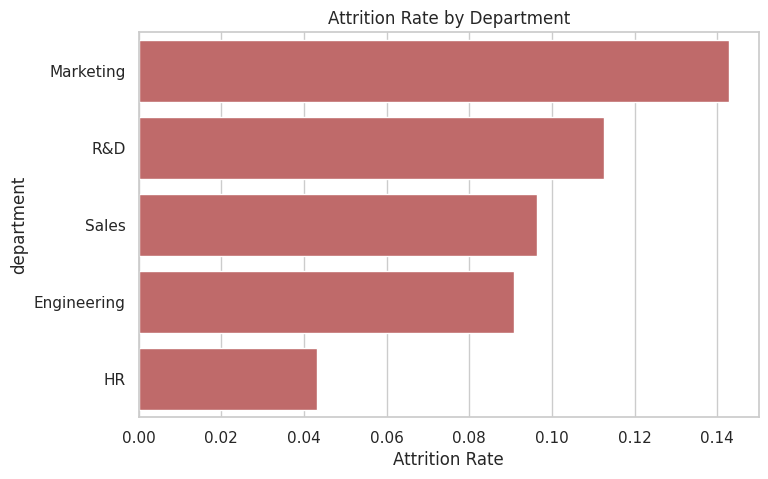

In [12]:
dept_attrition = (
    df_hr.groupby("department")["attrition"]
    .apply(lambda s: (s == "Yes").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=dept_attrition.values, y=dept_attrition.index, color="indianred")
plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate")
plt.show()


### 2.4 Attrition vs Satisfaction & Overtime

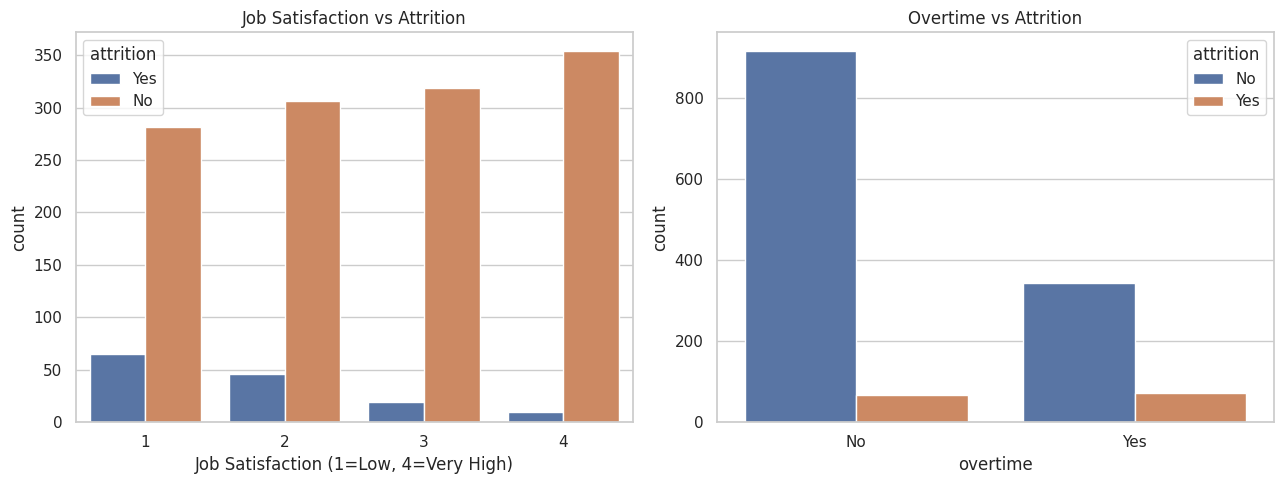

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_hr, x="job_satisfaction", hue="attrition", ax=axes[0])
axes[0].set_title("Job Satisfaction vs Attrition")
axes[0].set_xlabel("Job Satisfaction (1=Low, 4=Very High)")

sns.countplot(data=df_hr, x="overtime", hue="attrition", ax=axes[1])
axes[1].set_title("Overtime vs Attrition")

plt.tight_layout()
plt.show()


### 2.5 Tenure & Income Patterns

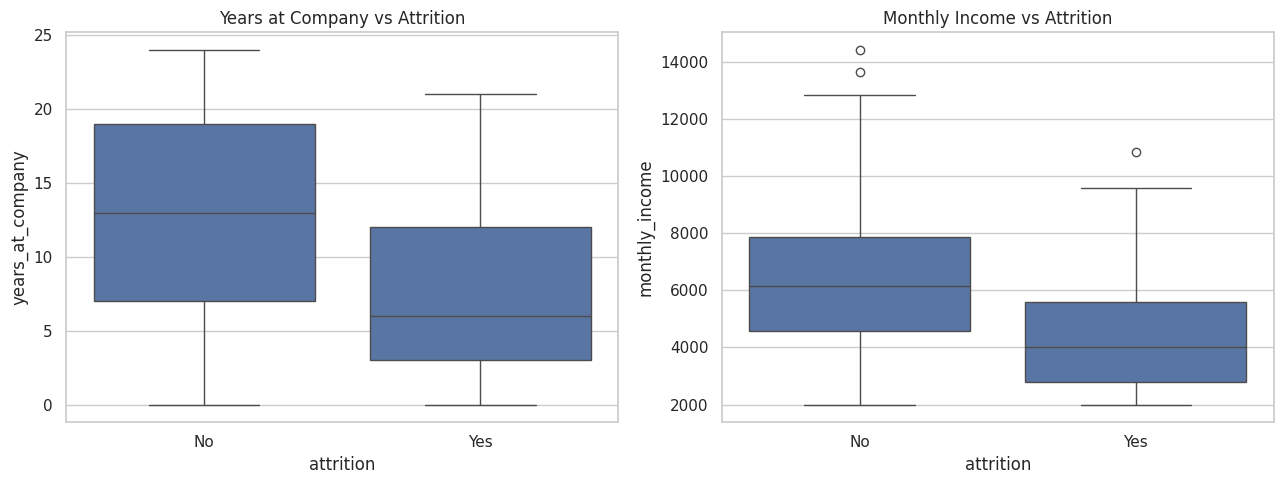

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_hr, x="attrition", y="years_at_company", ax=axes[0])
axes[0].set_title("Years at Company vs Attrition")

sns.boxplot(data=df_hr, x="attrition", y="monthly_income", ax=axes[1])
axes[1].set_title("Monthly Income vs Attrition")

plt.tight_layout()
plt.show()


### 2.6 Correlation Overview

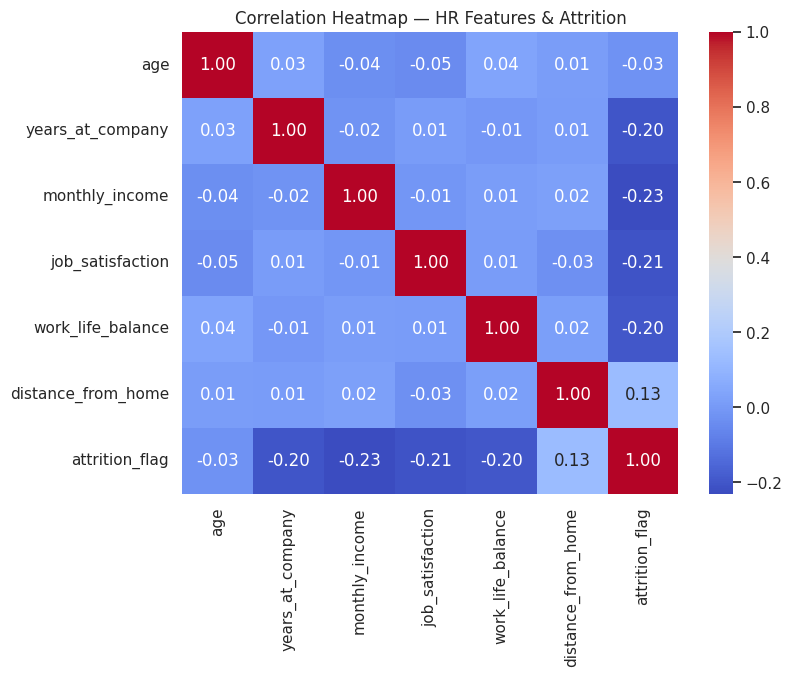

In [15]:
numeric_cols = ["age", "years_at_company", "monthly_income", "job_satisfaction",
                "work_life_balance", "distance_from_home"]

df_hr_corr = df_hr.copy()
df_hr_corr["attrition_flag"] = (df_hr_corr["attrition"] == "Yes").astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(df_hr_corr[numeric_cols + ["attrition_flag"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap — HR Features & Attrition")
plt.show()


### 2.7 Distance from Home vs Attrition

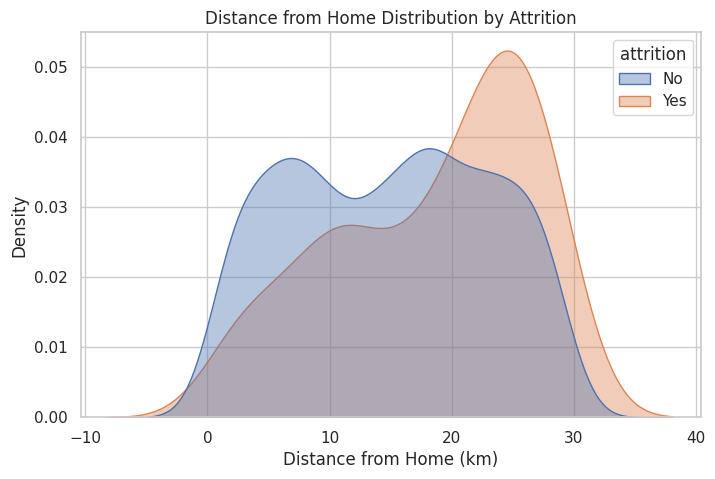

In [16]:
sns.kdeplot(data=df_hr, x="distance_from_home", hue="attrition", fill=True, common_norm=False, alpha=0.4)
plt.title("Distance from Home Distribution by Attrition")
plt.xlabel("Distance from Home (km)")
plt.show()
